In [1]:
!pip install pillow matplotlib

   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/7.0 MB 2.8 MB/s eta 0:00:03
   ----- ---------------------------------- 1.0/7.0 MB 2.5 MB/s eta 0:00:03
   ------- -------------------------------- 1.3/7.0 MB 2.5 MB/s eta 0:00:03
   ---------- ----------------------------- 1.8/7.0 MB 2.5 MB/s eta 0:00:03
   ------------- -------------------------- 2.4/7.0 MB 2.5 MB/s eta 0:00:02
   ---------------- ----------------------- 2.9/7.0 MB 2.5 MB/s eta 0:00:02
   ------------------- -------------------- 3.4/7.0 MB 2.4 MB/s eta 0:00:02
   ---------------------- ----------------- 3.9/7.0 MB 2.4 MB/s eta 0:00:02
   ------------------------- -------------- 4.5/7.0 MB 2.5 MB/s eta 0:00:02
   ---------------------------- ----------- 5.0/7.0 MB 2.5 MB/s eta 0:00:01
   ----------------------------- ---------- 5.2/7.0 MB 2.5 MB/s eta 0:00:01
   -------------------------------- ------- 5.8/7.0 MB 2.4 MB/s eta 0:00:01
   ----------------

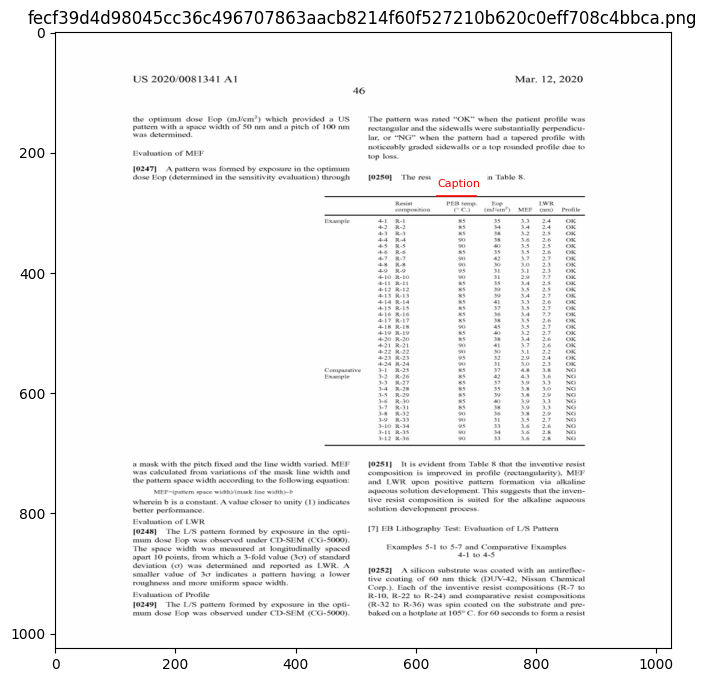

In [3]:
import json
import os
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ---- paths ----
COCO_JSON = "data/DocLayNet/COCO/val.json"
IMAGE_DIR = "data/DocLayNet/PNG"   # folder containing PNGs

# list of png filenames you want to visualize
TARGET_IMAGES = {
    "fecf39d4d98045cc36c496707863aacb8214f60f527210b620c0eff708c4bbca.png"
}

# ---- load coco ----
with open(COCO_JSON, "r") as f:
    coco = json.load(f)

# build helper maps
image_by_id = {img["id"]: img for img in coco["images"]}
image_by_name = {img["file_name"]: img for img in coco["images"]}
category_by_id = {cat["id"]: cat["name"] for cat in coco["categories"]}

# group annotations by image_id
annotations_by_image = {}
for ann in coco["annotations"]:
    annotations_by_image.setdefault(ann["image_id"], []).append(ann)

# ---- visualize ----
for fname in TARGET_IMAGES:
    if fname not in image_by_name:
        print(f"⚠️ {fname} not found in COCO images")
        continue

    img_info = image_by_name[fname]
    img_path = os.path.join(IMAGE_DIR, fname)

    image = Image.open(img_path).convert("RGB")

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(image)
    ax.set_title(fname)
    ax.axis("off")

    for ann in annotations_by_image.get(img_info["id"], []):
        x, y, w, h = ann["bbox"]
        cat_name = category_by_id.get(ann["category_id"], "unknown")
        if cat_name.lower() != "caption":
            continue

        rect = patches.Rectangle(
            (x, y),
            w,
            h,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )
        ax.add_patch(rect)

        ax.text(
            x,
            y - 3,
            cat_name,
            color="red",
            fontsize=8,
            backgroundcolor="white"
        )

    plt.show()

Processing 4994 images...


KeyboardInterrupt: 

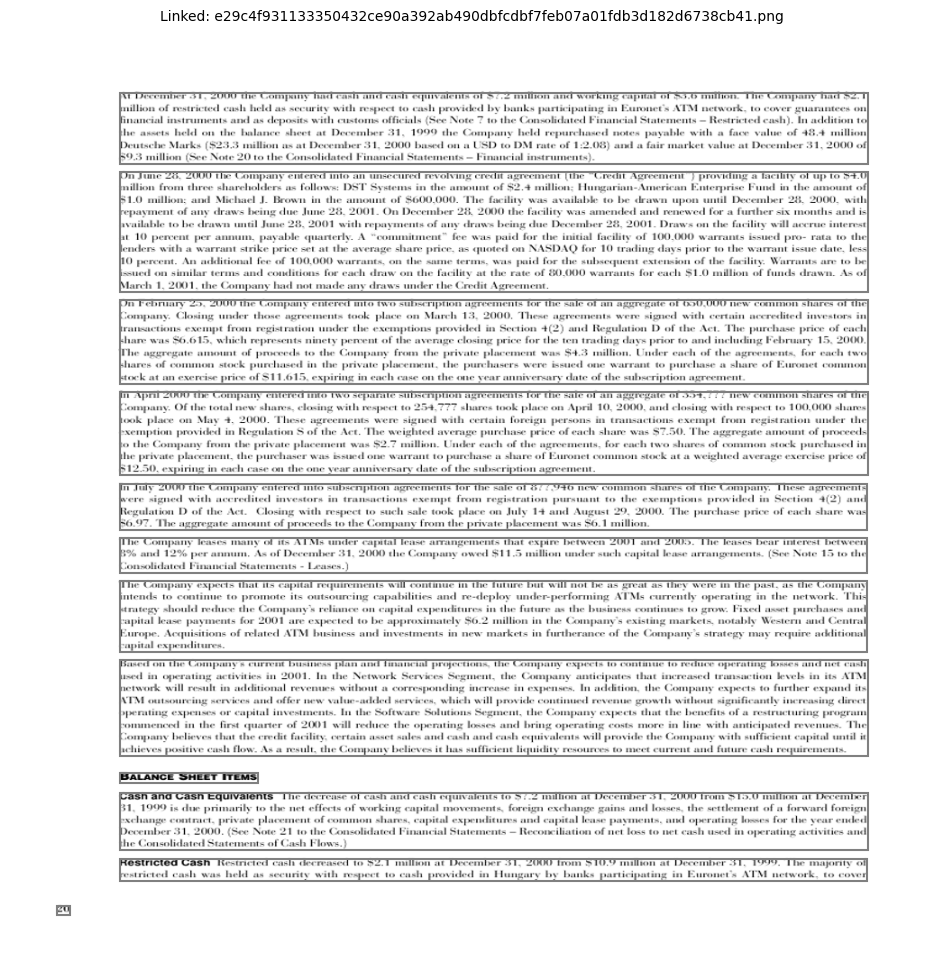

In [19]:
import json
import os
import math
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.optimize import linear_sum_assignment

# ==========================================
# CONFIGURATION
# ==========================================
COCO_JSON = "data/COCO/test.json"  # Path to your COCO JSON
IMAGE_DIR = "data/PNG"             # Path to your images
OUT_DIR = "test_folder_linked"     # Output directory

# DocLayNet Category IDs
CAT = {
    "Caption": 1,
    "Picture": 7,
    "Table": 9,
}

# Heuristic Constants
HORIZONTAL_PENALTY = 10.0   # Multiplier for x-distance (High = strict columns)
MAX_COST_THRESHOLD = 2000   # Max allowed weighted distance to draw a line

# ==========================================
# HELPER FUNCTIONS
# ==========================================
def get_center(bbox):
    """Returns the center (x, y) of a bounding box."""
    return (bbox[0] + bbox[2] / 2, bbox[1] + bbox[3] / 2)

def get_smart_cost(obj_bbox, cap_bbox):
    """
    Calculates a weighted distance between an object and a caption.
    Heavily penalizes horizontal misalignment to keep links within columns.
    """
    o_cx, o_cy = get_center(obj_bbox)
    c_cx, c_cy = get_center(cap_bbox)
    
    dx = abs(o_cx - c_cx)
    dy = abs(o_cy - c_cy)
    
    # 1. Smart Weighting:
    # Multiply dx by a large factor so that a small horizontal offset 
    # costs as much as a huge vertical distance.
    weighted_dx = dx * HORIZONTAL_PENALTY
    
    # 2. Hard Cutoff (Optional optimization):
    # If they are essentially in different columns (e.g., > 400px apart horizontally),
    # return a massive cost immediately.
    if dx > 400: 
        return 1e6
        
    return math.sqrt(weighted_dx**2 + dy**2)

# ==========================================
# MAIN EXECUTION
# ==========================================
def main():
    # Ensure output directory exists
    os.makedirs(OUT_DIR, exist_ok=True)

    # Load COCO Annotations
    with open(COCO_JSON) as f:
        coco = json.load(f)

    image_map = {i["id"]: i for i in coco["images"]}
    cat_map = {c["id"]: c["name"] for c in coco["categories"]}

    # Group annotations by image_id
    anns_by_image = {}
    for a in coco["annotations"]:
        anns_by_image.setdefault(a["image_id"], []).append(a)

    print(f"Processing {len(anns_by_image)} images...")

    for image_id, anns in anns_by_image.items():
        img_info = image_map[image_id]
        img_path = os.path.join(IMAGE_DIR, img_info["file_name"])

        if not os.path.exists(img_path):
            print(f"Skipping missing image: {img_info['file_name']}")
            continue

        # Load Image
        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            print(f"Error loading {img_info['file_name']}: {e}")
            continue

        fig, ax = plt.subplots(figsize=(12, 12))
        ax.imshow(image)
        ax.axis("off")

        # Separate Figures and Captions
        figures = [a for a in anns if a["category_id"] in (CAT["Picture"], CAT["Table"])]
        captions = [a for a in anns if a["category_id"] == CAT["Caption"]]

        # Draw all bounding boxes first
        for a in anns:
            x, y, w, h = a["bbox"]
            cname = cat_map.get(a["category_id"], "Unknown")
            
            color = "gray"
            if cname == "Picture": color = "blue"
            elif cname == "Table": color = "green"
            elif cname == "Caption": color = "orange"
            
            # Draw Box
            ax.add_patch(patches.Rectangle((x, y), w, h, fill=False, edgecolor=color, linewidth=1.5))
            
            # Optional: Add Label (helps debugging)
            # ax.text(x, y, cname, fontsize=8, color=color, verticalalignment='bottom')

        # ---------------------------------------------------------
        # ALGORITHM: One-to-One Global Matching with Cost Matrix
        # ---------------------------------------------------------
        if figures and captions:
            # 1. Build Cost Matrix (Rows=Captions, Cols=Figures)
            cost_matrix = np.zeros((len(captions), len(figures)))
            
            for i, cap in enumerate(captions):
                for j, obj in enumerate(figures):
                    cost_matrix[i, j] = get_smart_cost(obj["bbox"], cap["bbox"])

            # 2. Apply Hungarian Algorithm (Linear Sum Assignment)
            # This finds the unique set of pairings that minimizes the TOTAL cost of the page.
            cap_indices, fig_indices = linear_sum_assignment(cost_matrix)

            # 3. Draw Valid Connections
            for cap_idx, fig_idx in zip(cap_indices, fig_indices):
                current_cost = cost_matrix[cap_idx, fig_idx]
                
                # SAFETY VALVE:
                # Even if this is the "best" match globally, if the distance is huge 
                # (e.g., across the page), ignore it. This handles cases where 
                # we have extra captions that simply don't belong to any figure.
                if current_cost > MAX_COST_THRESHOLD:
                    continue

                obj = figures[fig_idx]
                cap = captions[cap_idx]

                o_cx, o_cy = get_center(obj["bbox"])
                c_cx, c_cy = get_center(cap["bbox"])

                # Draw Line
                ax.plot([o_cx, c_cx], [o_cy, c_cy], color="red", linewidth=2.5, alpha=0.8, marker='o', markersize=4)

        # Save Result
        out_path = os.path.join(OUT_DIR, os.path.splitext(img_info["file_name"])[0] + "_linked.png")
        plt.title(f"Linked: {img_info['file_name']}", fontsize=10)
        plt.savefig(out_path, bbox_inches="tight", dpi=150)
        plt.close()

    print(f"Done! Check results in '{OUT_DIR}'")

if __name__ == "__main__":
    main()

KeyboardInterrupt: 

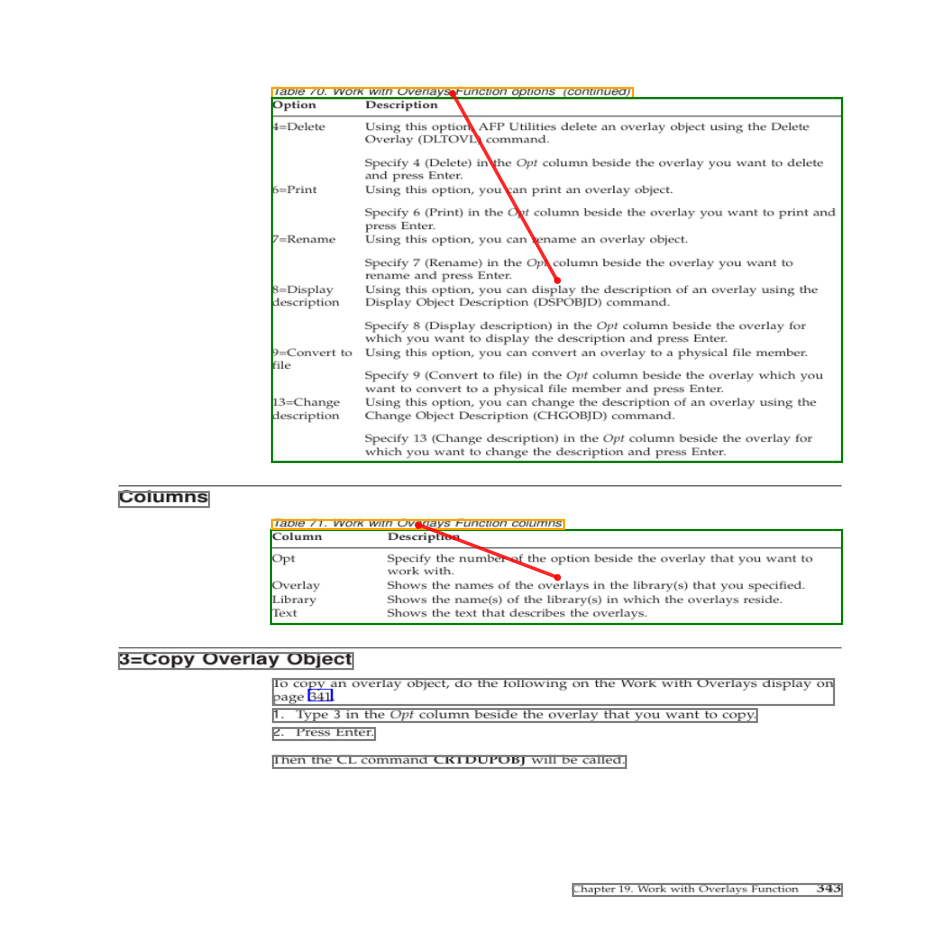

In [20]:
import json
import os
import math
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.optimize import linear_sum_assignment

# ==========================================
# CONFIGURATION
# ==========================================
COCO_JSON = "data/COCO/test.json"
IMAGE_DIR = "data/PNG"
OUT_DIR = "test_folder_linked"

CAT = {
    "Caption": 1,
    "Picture": 7,
    "Table": 9,
}

MAX_COST_THRESHOLD = 5.0

# ==========================================
# GEOMETRY HELPERS
# ==========================================
def bbox_center(b):
    return (b[0] + b[2] / 2, b[1] + b[3] / 2)

def edge_distance(fig_bbox, cap_bbox):
    """
    Distance from caption center to nearest edge of figure bbox.
    """
    fx, fy, fw, fh = fig_bbox
    cx, cy, cw, ch = cap_bbox

    cap_cx = cx + cw / 2
    cap_cy = cy + ch / 2

    left   = fx
    right  = fx + fw
    top    = fy
    bottom = fy + fh

    dx = max(left - cap_cx, 0, cap_cx - right)
    dy = max(top - cap_cy, 0, cap_cy - bottom)

    return math.hypot(dx, dy)

# ==========================================
# COST FUNCTION
# ==========================================
def get_layout_aware_cost(fig, cap):
    fb = fig["bbox"]
    cb = cap["bbox"]

    fx, fy, fw, fh = fb
    cx, cy, cw, ch = cb

    cap_center_y = cy + ch / 2

    # 1. Edge distance normalized by figure size
    dist = edge_distance(fb, cb)
    norm_dist = dist / max(fw, fh)

    # 2. Vertical semantic penalty
    vertical_penalty = 0.0
    fig_top = fy
    fig_bottom = fy + fh

    if fig["category_id"] == CAT["Picture"]:
        # captions should be BELOW images
        if cap_center_y < fig_top:
            vertical_penalty = 2.0
    elif fig["category_id"] == CAT["Table"]:
        # captions should be ABOVE tables
        if cap_center_y > fig_bottom:
            vertical_penalty = 2.0

    # 3. Horizontal overlap (column alignment)
    overlap_x = max(
        0,
        min(fx + fw, cx + cw) - max(fx, cx)
    )
    overlap_ratio = overlap_x / min(fw, cw)

    overlap_penalty = 0.0 if overlap_ratio > 0.2 else 1.5

    return norm_dist + vertical_penalty + overlap_penalty

# ==========================================
# MAIN
# ==========================================
def main():
    os.makedirs(OUT_DIR, exist_ok=True)

    with open(COCO_JSON) as f:
        coco = json.load(f)

    image_map = {i["id"]: i for i in coco["images"]}
    cat_map = {c["id"]: c["name"] for c in coco["categories"]}

    anns_by_image = {}
    for a in coco["annotations"]:
        anns_by_image.setdefault(a["image_id"], []).append(a)

    for image_id, anns in anns_by_image.items():
        img_info = image_map[image_id]
        img_path = os.path.join(IMAGE_DIR, img_info["file_name"])

        if not os.path.exists(img_path):
            continue

        try:
            image = Image.open(img_path).convert("RGB")
        except:
            continue

        fig, ax = plt.subplots(figsize=(12, 12))
        ax.imshow(image)
        ax.axis("off")

        figures = [a for a in anns if a["category_id"] in (CAT["Picture"], CAT["Table"])]
        captions = [a for a in anns if a["category_id"] == CAT["Caption"]]

        # Draw bounding boxes
        for a in anns:
            x, y, w, h = a["bbox"]
            cname = cat_map.get(a["category_id"], "Unknown")

            color = "gray"
            if cname == "Picture":
                color = "blue"
            elif cname == "Table":
                color = "green"
            elif cname == "Caption":
                color = "orange"

            ax.add_patch(
                patches.Rectangle(
                    (x, y), w, h,
                    fill=False, edgecolor=color, linewidth=1.5
                )
            )

        # -------------------------------------------------
        # MATCHING
        # -------------------------------------------------
        if figures and captions:
            cost_matrix = np.full((len(captions), len(figures)), 1e6)

            for i, cap in enumerate(captions):
                for j, fig_ann in enumerate(figures):
                    cost_matrix[i, j] = get_layout_aware_cost(fig_ann, cap)

            cap_idx, fig_idx = linear_sum_assignment(cost_matrix)

            for c_i, f_i in zip(cap_idx, fig_idx):
                cost = cost_matrix[c_i, f_i]
                if cost > MAX_COST_THRESHOLD:
                    continue

                cap = captions[c_i]
                fig_ann = figures[f_i]

                cx, cy = bbox_center(cap["bbox"])
                fx, fy = bbox_center(fig_ann["bbox"])

                ax.plot(
                    [fx, cx],
                    [fy, cy],
                    color="red",
                    linewidth=2.5,
                    alpha=0.85,
                    marker="o",
                    markersize=4
                )

        out_path = os.path.join(
            OUT_DIR,
            os.path.splitext(img_info["file_name"])[0] + "_linked.png"
        )
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        plt.close()

if __name__ == "__main__":
    main()


In [31]:
import json
import os
import math
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.optimize import linear_sum_assignment

# ==========================================
# CONFIGURATION
# ==========================================
COCO_JSON = "data/COCO/test.json"
IMAGE_DIR = "data/PNG"
OUT_DIR = "test_folder_linked"

CAT = {
    "Caption": 1,
    "Picture": 7,
    "Table": 9,
}

MAX_COST_THRESHOLD = 5.0

# ==========================================
# GEOMETRY HELPERS
# ==========================================
def bbox_center(b):
    return (b[0] + b[2] / 2, b[1] + b[3] / 2)

def edge_distance(fig_bbox, cap_bbox):
    """
    Distance from caption center to nearest edge of figure bbox.
    """
    fx, fy, fw, fh = fig_bbox
    cx, cy, cw, ch = cap_bbox

    cap_cx = cx + cw / 2
    cap_cy = cy + ch / 2

    left   = fx
    right  = fx + fw
    top    = fy
    bottom = fy + fh

    dx = max(left - cap_cx, 0, cap_cx - right)
    dy = max(top - cap_cy, 0, cap_cy - bottom)

    return math.hypot(dx, dy)

# ==========================================
# COST FUNCTION
# ==========================================
def get_layout_aware_cost(fig, cap):
    fb = fig["bbox"]
    cb = cap["bbox"]

    fx, fy, fw, fh = fb
    cx, cy, cw, ch = cb

    cap_center_y = cy + ch / 2

    # 1. Edge distance normalized by figure size
    dist = edge_distance(fb, cb)
    norm_dist = dist / (0.5 max(fw, fh))

    # 2. Vertical semantic penalty
    vertical_penalty = 0.0
    fig_top = fy
    fig_bottom = fy + fh

    if fig["category_id"] == CAT["Picture"]:
        # captions should be BELOW images
        if cap_center_y < fig_top:
            vertical_penalty = 2.0
    elif fig["category_id"] == CAT["Table"]:
        # captions should be ABOVE tables
        if cap_center_y > fig_bottom:
            vertical_penalty = 2.0

    # 3. Horizontal overlap (column alignment)
    overlap_x = max(
        0,
        min(fx + fw, cx + cw) - max(fx, cx)
    )
    overlap_ratio = overlap_x / min(fw, cw)

    overlap_penalty = 0.0 if overlap_ratio > 0.2 else 1.5

    return norm_dist + vertical_penalty + overlap_penalty

# ==========================================
# MAIN
# ==========================================
def main():
    os.makedirs(OUT_DIR, exist_ok=True)

    with open(COCO_JSON) as f:
        coco = json.load(f)

    image_map = {i["id"]: i for i in coco["images"]}
    cat_map = {c["id"]: c["name"] for c in coco["categories"]}

    anns_by_image = {}
    for a in coco["annotations"]:
        anns_by_image.setdefault(a["image_id"], []).append(a)

    for image_id, anns in anns_by_image.items():
        img_info = image_map[image_id]
        img_path = os.path.join(IMAGE_DIR, img_info["file_name"])

        if not os.path.exists(img_path):
            continue

        try:
            image = Image.open(img_path).convert("RGB")
        except:
            continue

        fig, ax = plt.subplots(figsize=(12, 12))
        ax.imshow(image)
        ax.axis("off")

        figures = [a for a in anns if a["category_id"] in (CAT["Picture"], CAT["Table"])]
        captions = [a for a in anns if a["category_id"] == CAT["Caption"]]

        # Draw bounding boxes
        for a in anns:
            x, y, w, h = a["bbox"]
            cname = cat_map.get(a["category_id"], "Unknown")

            color = "gray"
            if cname == "Picture":
                color = "blue"
            elif cname == "Table":
                color = "green"
            elif cname == "Caption":
                color = "orange"

            ax.add_patch(
                patches.Rectangle(
                    (x, y), w, h,
                    fill=False, edgecolor=color, linewidth=1.5
                )
            )

        # -------------------------------------------------
        # MATCHING
        # -------------------------------------------------
        if figures and captions:
            cost_matrix = np.full((len(captions), len(figures)), 1e6)

            for i, cap in enumerate(captions):
                for j, fig_ann in enumerate(figures):
                    cost_matrix[i, j] = get_layout_aware_cost(fig_ann, cap)

            cap_idx, fig_idx = linear_sum_assignment(cost_matrix)

            for c_i, f_i in zip(cap_idx, fig_idx):
                cost = cost_matrix[c_i, f_i]
                if cost > MAX_COST_THRESHOLD:
                    continue

                cap = captions[c_i]
                fig_ann = figures[f_i]

                cx, cy = bbox_center(cap["bbox"])
                fx, fy = bbox_center(fig_ann["bbox"])

                ax.plot(
                    [fx, cx],
                    [fy, cy],
                    color="red",
                    linewidth=2.5,
                    alpha=0.85,
                    marker="o",
                    markersize=4
                )

        out_path = os.path.join(
            OUT_DIR,
            os.path.splitext(img_info["file_name"])[0] + "_linked.png"
        )
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        plt.close()

if __name__ == "__main__":
    main()


SyntaxError: invalid syntax. Perhaps you forgot a comma? (125531629.py, line 65)

# Prob the best

KeyboardInterrupt: 

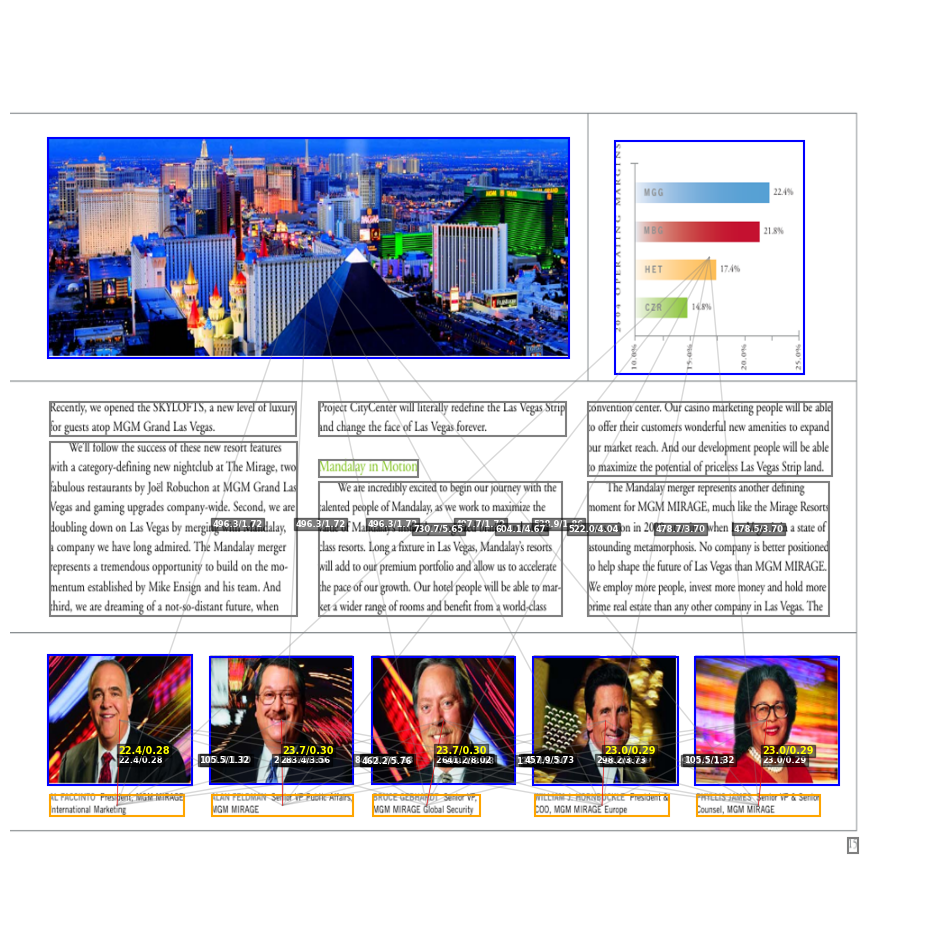

In [33]:
import json
import os
import math
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ==========================================
# CONFIGURATION
# ==========================================
COCO_JSON = "data/COCO/test.json"
IMAGE_DIR = "data/PNG"
OUT_DIR = "test_folder_linked_debug"

CAT = {
    "Caption": 1,
    "Picture": 7,
    "Table": 9,
}

# ==========================================
# GEOMETRY HELPERS
# ==========================================
def bbox_center(b):
    return (b[0] + b[2] / 2, b[1] + b[3] / 2)

def edge_distance(fig_bbox, cap_bbox):
    fx, fy, fw, fh = fig_bbox
    cx, cy, cw, ch = cap_bbox

    cap_cx = cx + cw / 2
    cap_cy = cy + ch / 2

    left   = fx
    right  = fx + fw
    top    = fy
    bottom = fy + fh

    dx = max(left - cap_cx, 0, cap_cx - right)
    dy = max(top - cap_cy, 0, cap_cy - bottom)

    return math.hypot(dx, dy)

def get_layout_aware_cost(fig, cap):
    fb = fig["bbox"]
    dist = edge_distance(fb, cap["bbox"])
    norm_dist = dist / (0.5 * max(fb[2], fb[3]))
    return dist, norm_dist

# ==========================================
# MAIN
# ==========================================
def main():
    os.makedirs(OUT_DIR, exist_ok=True)

    with open(COCO_JSON) as f:
        coco = json.load(f)

    image_map = {i["id"]: i for i in coco["images"]}
    cat_map = {c["id"]: c["name"] for c in coco["categories"]}

    anns_by_image = {}
    for a in coco["annotations"]:
        anns_by_image.setdefault(a["image_id"], []).append(a)

    for image_id, anns in anns_by_image.items():
        img_info = image_map[image_id]
        img_path = os.path.join(IMAGE_DIR, img_info["file_name"])

        if not os.path.exists(img_path):
            continue

        try:
            image = Image.open(img_path).convert("RGB")
        except:
            continue

        fig, ax = plt.subplots(figsize=(12, 12))
        ax.imshow(image)
        ax.axis("off")

        figures = [a for a in anns if a["category_id"] in (CAT["Picture"], CAT["Table"])]
        captions = [a for a in anns if a["category_id"] == CAT["Caption"]]

        # Draw bounding boxes
        for a in anns:
            x, y, w, h = a["bbox"]
            cname = cat_map.get(a["category_id"], "Unknown")

            color = "gray"
            if cname == "Picture":
                color = "blue"
            elif cname == "Table":
                color = "green"
            elif cname == "Caption":
                color = "orange"

            ax.add_patch(
                patches.Rectangle(
                    (x, y), w, h,
                    fill=False, edgecolor=color, linewidth=1.5
                )
            )

        if figures and captions:
            # Compute all distances
            pairs = []
            for i, cap in enumerate(captions):
                for j, fig_ann in enumerate(figures):
                    rd, nd = get_layout_aware_cost(fig_ann, cap)
                    pairs.append((nd, rd, i, j))  # (norm_dist, real_dist, caption_idx, figure_idx)

            # Draw all possible links in gray
            for nd, rd, i, j in pairs:
                cx, cy = bbox_center(captions[i]["bbox"])
                fx, fy = bbox_center(figures[j]["bbox"])
                ax.plot([fx, cx], [fy, cy], color="gray", linewidth=1, alpha=0.3)
                mx, my = (fx + cx) / 2, (fy + cy) / 2
                ax.text(mx, my, f"{rd:.1f}/{nd:.2f}", color="white",
                        fontsize=6, fontweight="bold",
                        bbox=dict(facecolor='black', alpha=0.5, pad=1))

            # -------------------------------
            # Greedy closest-per-caption, one-to-one assignment
            # -------------------------------
            pairs.sort()  # sort by normalized distance ascending
            assigned_figures = set()
            assigned_captions = set()
            final_links = []

            for nd, rd, i, j in pairs:
                if i in assigned_captions or j in assigned_figures:
                    continue
                assigned_captions.add(i)
                assigned_figures.add(j)
                final_links.append((i, j, rd, nd))

            # Draw final links in red
            max_norm = max(nd for _, _, _, nd in final_links) if final_links else 1.0
            for i, j, rd, nd in final_links:
                cx, cy = bbox_center(captions[i]["bbox"])
                fx, fy = bbox_center(figures[j]["bbox"])
                lw = 3.0 * (1 - nd / (max_norm + 1e-6))
                lw = max(lw, 0.5)
                ax.plot([fx, cx], [fy, cy], color="red", linewidth=lw, alpha=0.9)
                mx, my = (fx + cx) / 2, (fy + cy) / 2
                ax.text(mx, my - 10, f"{rd:.1f}/{nd:.2f}", color="yellow",
                        fontsize=7, fontweight="bold",
                        bbox=dict(facecolor='black', alpha=0.5, pad=1))

        out_path = os.path.join(
            OUT_DIR,
            os.path.splitext(img_info["file_name"])[0] + "_linked_debug.png"
        )
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        plt.close()


if __name__ == "__main__":
    main()


# Hungarian

KeyboardInterrupt: 

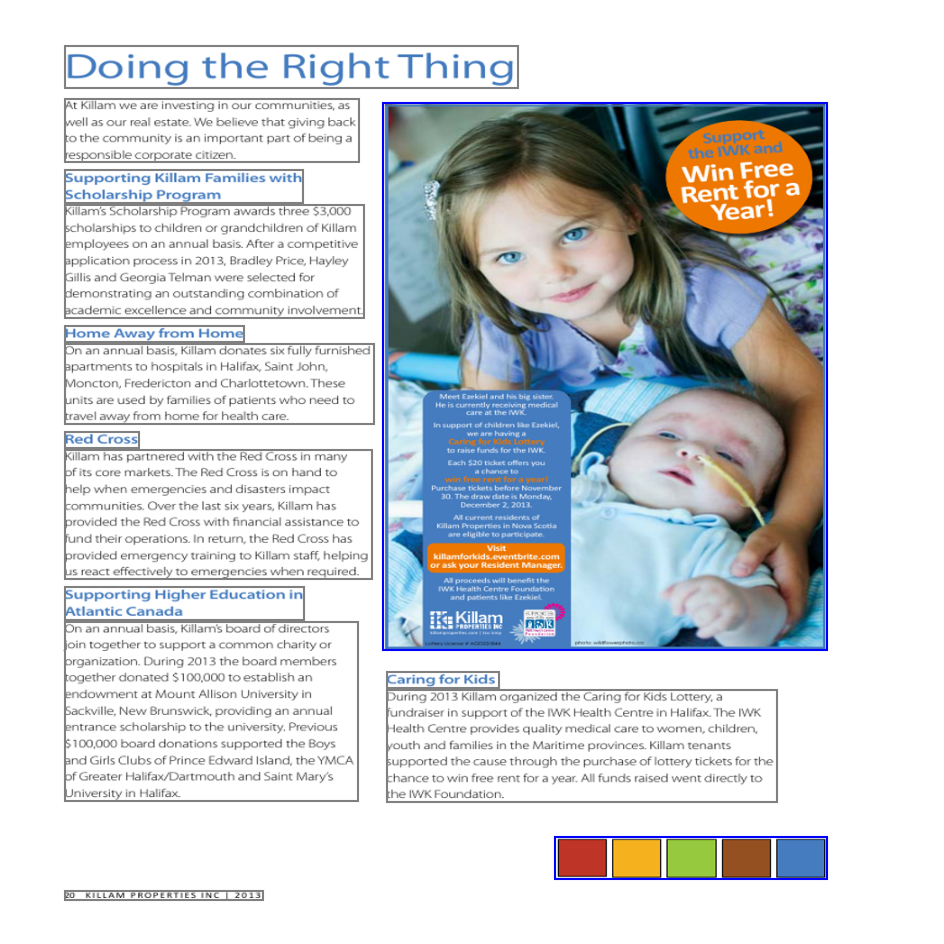

In [34]:
import json
import os
import math
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.optimize import linear_sum_assignment

# ==========================================
# CONFIGURATION
# ==========================================
COCO_JSON = "data/COCO/test.json"
IMAGE_DIR = "data/PNG"
OUT_DIR = "test_folder_linked_debug_hungarian"

CAT = {
    "Caption": 1,
    "Picture": 7,
    "Table": 9,
}

# ==========================================
# GEOMETRY HELPERS
# ==========================================
def bbox_center(b):
    return (b[0] + b[2] / 2, b[1] + b[3] / 2)

def edge_distance(fig_bbox, cap_bbox):
    fx, fy, fw, fh = fig_bbox
    cx, cy, cw, ch = cap_bbox

    cap_cx = cx + cw / 2
    cap_cy = cy + ch / 2

    left   = fx
    right  = fx + fw
    top    = fy
    bottom = fy + fh

    dx = max(left - cap_cx, 0, cap_cx - right)
    dy = max(top - cap_cy, 0, cap_cy - bottom)

    return math.hypot(dx, dy)

def get_layout_aware_cost(fig, cap):
    fb = fig["bbox"]
    dist = edge_distance(fb, cap["bbox"])
    norm_dist = dist / (0.5 * max(fb[2], fb[3]))
    return dist, norm_dist

# ==========================================
# MAIN
# ==========================================
def main():
    os.makedirs(OUT_DIR, exist_ok=True)

    with open(COCO_JSON) as f:
        coco = json.load(f)

    image_map = {i["id"]: i for i in coco["images"]}
    cat_map = {c["id"]: c["name"] for c in coco["categories"]}

    anns_by_image = {}
    for a in coco["annotations"]:
        anns_by_image.setdefault(a["image_id"], []).append(a)

    for image_id, anns in anns_by_image.items():
        img_info = image_map[image_id]
        img_path = os.path.join(IMAGE_DIR, img_info["file_name"])

        if not os.path.exists(img_path):
            continue

        try:
            image = Image.open(img_path).convert("RGB")
        except:
            continue

        fig, ax = plt.subplots(figsize=(12, 12))
        ax.imshow(image)
        ax.axis("off")

        figures = [a for a in anns if a["category_id"] in (CAT["Picture"], CAT["Table"])]
        captions = [a for a in anns if a["category_id"] == CAT["Caption"]]

        # Draw bounding boxes
        for a in anns:
            x, y, w, h = a["bbox"]
            cname = cat_map.get(a["category_id"], "Unknown")

            color = "gray"
            if cname == "Picture":
                color = "blue"
            elif cname == "Table":
                color = "green"
            elif cname == "Caption":
                color = "orange"

            ax.add_patch(
                patches.Rectangle(
                    (x, y), w, h,
                    fill=False, edgecolor=color, linewidth=1.5
                )
            )

        if figures and captions:
            # Compute all distances
            pairs = []
            
            cost_matrix = np.zeros((len(captions), len(figures)))
            real_dist_matrix = np.zeros_like(cost_matrix)
            
            for i, cap in enumerate(captions):
                for j, fig_ann in enumerate(figures):
                    rd, nd = get_layout_aware_cost(fig_ann, cap)
                    cost_matrix[i, j] = nd
                    real_dist_matrix[i, j] = rd
            
            # Solve Hungarian
            cap_idx, fig_idx = linear_sum_assignment(cost_matrix)
            
            # Draw final links in red
            max_norm = cost_matrix.max() if cost_matrix.size > 0 else 1.0
            for c_i, f_i in zip(cap_idx, fig_idx):
                cx, cy = bbox_center(captions[c_i]["bbox"])
                fx, fy = bbox_center(figures[f_i]["bbox"])
                rd = real_dist_matrix[c_i, f_i]
                nd = cost_matrix[c_i, f_i]
            
                lw = 3.0 * (1 - nd / (max_norm + 1e-6))
                lw = max(lw, 0.5)
                ax.plot([fx, cx], [fy, cy], color="red", linewidth=lw, alpha=0.9)
            
                mx, my = (fx + cx) / 2, (fy + cy) / 2
                ax.text(mx, my - 10, f"{rd:.1f}/{nd:.2f}", color="yellow",
                        fontsize=7, fontweight="bold",
                        bbox=dict(facecolor='black', alpha=0.5, pad=1))

        out_path = os.path.join(
            OUT_DIR,
            os.path.splitext(img_info["file_name"])[0] + "_linked_debug.png"
        )
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        plt.close()


if __name__ == "__main__":
    main()
